In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Для работы с CUDA используется библиотека CuPy
import cupy as cp

In [3]:
# Тип используемого GPU
!nvidia-smi

Sun May 17 23:47:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Тип используемого CPU
!lscpu | grep "Model name"

Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz


In [5]:
# Код на C++ для CUDA - ядра
cuda_mass_search_src = r'''
extern "C" __global__
void gpu_mass_search_kernel(
    const unsigned char* patterns_arr,
    const unsigned char* text_buffer,
    int* match_matrix,
    int num_patterns,
    int pattern_len,
    int buffer_size)
{
    // Индекс символа в буфере (H)
    int x_idx = blockIdx.x * blockDim.x + threadIdx.x;

    // Индекс подстроки (N)
    int y_idx = blockIdx.y * blockDim.y + threadIdx.y;

    // Проверка границ массивов
    if (x_idx < buffer_size && y_idx < num_patterns)
    {
        for (int k = 0; k < pattern_len; ++k)
        {
            // Совпадение символа проверяемой подстроки с символом из буфера
            if (patterns_arr[y_idx * pattern_len + k] == text_buffer[x_idx])
            {
                int target_pos = x_idx - k;

                // Во избежание выхода за пределы рабочей матрицы
                if (target_pos >= 0 && target_pos < buffer_size)
                {
                    // Атомарное сложение (чтобы избежать проблему возникновения состояния гонки)
                    atomicSub(&match_matrix[y_idx * buffer_size + target_pos], 1);
                }
            }
        }
    }
}
'''
# Компилируем ядро
compiled_search_kernel = cp.RawKernel(cuda_mass_search_src, 'gpu_mass_search_kernel')

In [6]:
# Последовательный поиск на CPU без проведения предварительной индексации
def execute_cpu_naive_search(patterns, text_buf, result_matrix):

    num_patterns, pattern_len = patterns.shape
    buf_size = len(text_buf)

    for j in range(buf_size):
        for i in range(num_patterns):
            for k in range(pattern_len):
                if patterns[i, k] == text_buf[j]:
                    if j - k >= 0:
                        result_matrix[i, j - k] -= 1

    return result_matrix

In [7]:
# Вспомогательная функция для создания словаря вхождения символов
def build_character_index(alphabet, patterns):

    char_index = {char: [] for char in alphabet}
    num_patterns, pattern_len = patterns.shape

    for i in range(num_patterns):
        for k in range(pattern_len):
            char_index[patterns[i, k]].append((i, k))

    return char_index

In [8]:
# Поиск подстрок на CPU (с использованием словаря вхождений)
def execute_cpu_indexed_search(text_buf, char_index, result_matrix):

    for j, char_val in enumerate(text_buf):

        # Поиск совпадений для всех исследуемых подстрок
        for i, k in char_index[char_val]:
            if j - k >= 0:
                result_matrix[i, j - k] -= 1

    return result_matrix

In [9]:
# Поиск подстрок на GPU (CuPy)
def execute_gpu_search(patterns, text_buf, result_matrix):

    num_patterns, pattern_len = patterns.shape
    buffer_size = text_buf.size

    # Перенос данных в память GPU
    d_patterns = cp.asarray(patterns, dtype=cp.uint8)
    d_text_buf = cp.asarray(text_buf, dtype=cp.uint8)
    d_result_matrix = cp.asarray(result_matrix, dtype=cp.int32)

    # Конфигурация сетки блоков (256 потоков на блок)
    threads_per_block = (16, 16)
    blocks_per_grid_x = (buffer_size + threads_per_block[0] - 1) // threads_per_block[0]
    blocks_per_grid_y = (num_patterns + threads_per_block[1] - 1) // threads_per_block[1]

    # Запуск CUDA ядра
    compiled_search_kernel(
        (blocks_per_grid_x, blocks_per_grid_y),
        threads_per_block,
        (d_patterns, d_text_buf, d_result_matrix, num_patterns, pattern_len, buffer_size)
    )

    # Синхронизация потоков до полного окончания вычислений
    cp.cuda.Stream.null.synchronize()

    # Возвращение результата на CPU
    return cp.asnumpy(d_result_matrix)

In [10]:
# Функция сохранения исходных данных (2 файла формата CSV: для буфера и для подстрок)
def export_initial_data(patterns, text_buffer, base_filename="initial_data"):

    df_patterns = pd.DataFrame({
        "Pattern_ID": range(len(patterns)),
        "Pattern_String": [str(p) for p in patterns]
    })
    df_buffer = pd.DataFrame({"Text_Buffer": [str(text_buffer)]})

    file_patterns = f"{base_filename}_patterns.csv"
    file_buffer = f"{base_filename}_buffer.csv"

    df_patterns.to_csv(file_patterns, index=False)
    df_buffer.to_csv(file_buffer, index=False)

    print(f"Исходные данные сохранены: подстроки: {file_patterns} и буфер: {file_buffer}")

In [11]:
# Функция сохранения результатов поиска подстрок (подстрока, ее индекс и индекс первого элемента найденной подстроки )
def export_search_results(filename, patterns, match_indices, buffer_size, run_id):

    pattern_ids = match_indices[0]
    positions = match_indices[1]

    found_substrings = [str(patterns[pid]) for pid in pattern_ids]

    df_results = pd.DataFrame({
        "Run_ID": [run_id] * len(pattern_ids),
        "Buffer_Size": [buffer_size] * len(pattern_ids),
        "Substring_String": found_substrings,
        "Substring_ID": pattern_ids,
        "Start_Position": positions
    })

    file_exists = os.path.exists(filename)

    df_results.to_csv(filename, mode='a', header=not file_exists, index=False)

In [12]:
# Проведение вычислительных экспериментов
def orchestrate_benchmarks(sizes_list, lengths_list, iterations=3):

    alphabet = np.arange(256)
    benchmark_records = []

    result_csv_file = "search_results.csv"


    if os.path.exists(result_csv_file):
        os.remove(result_csv_file)

    # Прогревочный запуск
    _ = execute_gpu_search(
        np.ones((10, 2), dtype=np.uint8),
        np.ones(10, dtype=np.uint8),
        np.full((10, 10), 2, dtype=np.int32)
    )

    for p_len in lengths_list:
        for size in sizes_list:

            # Создаем буфер и подстроки
            patterns = np.random.randint(len(alphabet), size=(size, p_len), dtype=np.uint8)
            text_buffer = np.random.randint(len(alphabet), size=size, dtype=np.uint8)

            # Сохраняем исходные данные для первой итерации (для каждого размера)
            export_initial_data(patterns, text_buffer, f"input_L{p_len}_S{size}")

            char_index = build_character_index(alphabet, patterns)

            gpu_times, cpu_naive_times, cpu_indexed_times = [], [], []

            for _ in range(iterations):

                init_matrix = np.full((size, size), fill_value=p_len, dtype=np.int32)

                # Время на GPU
                t_start = time.time()
                gpu_result = execute_gpu_search(patterns, text_buffer, init_matrix.copy())
                gpu_times.append(time.time() - t_start)

                # Время на CPU (без оптимизации)
                t_start = time.time()
                cpu_naive_result = execute_cpu_naive_search(patterns, text_buffer, init_matrix.copy())
                cpu_naive_times.append(time.time() - t_start)

                # Время на CPU (с индексированием вхождений)
                t_start = time.time()
                cpu_indexed_result = execute_cpu_indexed_search(text_buffer, char_index, init_matrix.copy())
                cpu_indexed_times.append(time.time() - t_start)

            # Проверка корректности
            is_correct = np.array_equal(gpu_result, cpu_indexed_result)

            # Извлекаем индексы совпадений (в случае зануления матрицы)
            matches = np.where(gpu_result == 0)
            run_id_title = f"Size_{size}_Len_{p_len}"
            export_search_results(result_csv_file, patterns, matches, size, run_id_title)

            # Добавление усредненных результатов
            benchmark_records.append({
                "Substring_Length": p_len,
                "Buffer_Size": size,
                "GPU_Time": np.mean(gpu_times),
                "CPU_Naive_Time": np.mean(cpu_naive_times),
                "CPU_Indexed_Time": np.mean(cpu_indexed_times),
                "Correctness": "PASS" if is_correct else "FAIL"
            })

            print(f"Буфер: {size:<5} | Длина подстр.: {p_len:<2} | GPU: {np.mean(gpu_times):.4f}c | "
                  f"CPU-N: {np.mean(cpu_naive_times):.4f}c | CPU-Idx: {np.mean(cpu_indexed_times):.4f}c | "
                  f"Статус: {'PASS' if is_correct else 'FAIL'}")

    df_benchmarks = pd.DataFrame(benchmark_records)

    # Расчет ускорения
    df_benchmarks["Accel_Naive"] = df_benchmarks["CPU_Naive_Time"] / df_benchmarks["GPU_Time"]
    df_benchmarks["Accel_Indexed"] = df_benchmarks["CPU_Indexed_Time"] / df_benchmarks["GPU_Time"]

    return df_benchmarks

In [13]:
# Создание графиков времени выполнения и ускорения для min и max длин подстрок
def visualize_performance(df):

    min_len = df['Substring_Length'].min()
    max_len = df['Substring_Length'].max()

    df_min = df[df['Substring_Length'] == min_len]
    df_max = df[df['Substring_Length'] == max_len]

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

    # Время вычислений (min длина)
    axes[0, 0].plot(df_min['Buffer_Size'], df_min['GPU_Time'], marker='o', lw=2, label="GPU", color='dodgerblue')
    axes[0, 0].plot(df_min['Buffer_Size'], df_min['CPU_Naive_Time'], marker='s', lw=2, label="CPU Без n_k", color='darkred')
    axes[0, 0].plot(df_min['Buffer_Size'], df_min['CPU_Indexed_Time'], marker='^', lw=2, label="CPU С n_k", color='orange')
    axes[0, 0].set_title(f"Время вычислений (Длина подстроки N = {min_len})", fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel("Размерность буфера (H)", fontsize=10)
    axes[0, 0].set_ylabel("Время (секунды)", fontsize=10)
    axes[0, 0].legend()
    axes[0, 0].grid(True, linestyle='--', alpha=0.6)

    # Время вычислений (max длина)
    axes[0, 1].plot(df_max['Buffer_Size'], df_max['GPU_Time'], marker='o', lw=2, label="GPU", color='dodgerblue')
    axes[0, 1].plot(df_max['Buffer_Size'], df_max['CPU_Naive_Time'], marker='s', lw=2, label="CPU Без n_k", color='darkred')
    axes[0, 1].plot(df_max['Buffer_Size'], df_max['CPU_Indexed_Time'], marker='^', lw=2, label="CPU С n_k", color='orange')
    axes[0, 1].set_title(f"Время вычислений (Длина подстроки N = {max_len})", fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel("Размерность буфера (H)", fontsize=10)
    axes[0, 1].set_ylabel("Время (секунды)", fontsize=10)
    axes[0, 1].legend()
    axes[0, 1].grid(True, linestyle='--', alpha=0.6)

    # Величина ускорения (min длина)
    axes[1, 0].plot(df_min['Buffer_Size'], df_min['Accel_Naive'], marker='s', lw=2, label="Относит. CPU Без n_k", color='forestgreen')
    axes[1, 0].plot(df_min['Buffer_Size'], df_min['Accel_Indexed'], marker='^', lw=2, label="Относит. CPU С n_k", color='purple')
    axes[1, 0].set_title(f"Ускорение GPU (Длина подстроки N = {min_len})", fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel("Размерность буфера (H)", fontsize=10)
    axes[1, 0].set_ylabel("Кратность ускорения", fontsize=10)
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle='--', alpha=0.6)

    # Величина ускорения (max длина)
    axes[1, 1].plot(df_max['Buffer_Size'], df_max['Accel_Naive'], marker='s', lw=2, label="Относит. CPU Без n_k", color='forestgreen')
    axes[1, 1].plot(df_max['Buffer_Size'], df_max['Accel_Indexed'], marker='^', lw=2, label="Относит. CPU С n_k", color='purple')
    axes[1, 1].set_title(f"Ускорение GPU (Длина подстроки N = {max_len})", fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel("Размерность буфера (H)", fontsize=10)
    axes[1, 1].set_ylabel("Кратность ускорения", fontsize=10)
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

Начало вычислительных экспериментов
Размерности буфера (H): [160, 320, 480, 640, 800, 960]
Длины подстрок (N): [2, 8]

Исходные данные сохранены: подстроки: input_L2_S160_patterns.csv и буфер: input_L2_S160_buffer.csv
Буфер: 160   | Длина подстр.: 2  | GPU: 0.0005c | CPU-N: 0.0283c | CPU-Idx: 0.0004c | Статус: PASS
Исходные данные сохранены: подстроки: input_L2_S320_patterns.csv и буфер: input_L2_S320_buffer.csv
Буфер: 320   | Длина подстр.: 2  | GPU: 0.0008c | CPU-N: 0.1065c | CPU-Idx: 0.0009c | Статус: PASS
Исходные данные сохранены: подстроки: input_L2_S480_patterns.csv и буфер: input_L2_S480_buffer.csv
Буфер: 480   | Длина подстр.: 2  | GPU: 0.0015c | CPU-N: 0.1425c | CPU-Idx: 0.0012c | Статус: PASS
Исходные данные сохранены: подстроки: input_L2_S640_patterns.csv и буфер: input_L2_S640_buffer.csv
Буфер: 640   | Длина подстр.: 2  | GPU: 0.0025c | CPU-N: 0.2219c | CPU-Idx: 0.0019c | Статус: PASS
Исходные данные сохранены: подстроки: input_L2_S800_patterns.csv и буфер: input_L2_S800_b

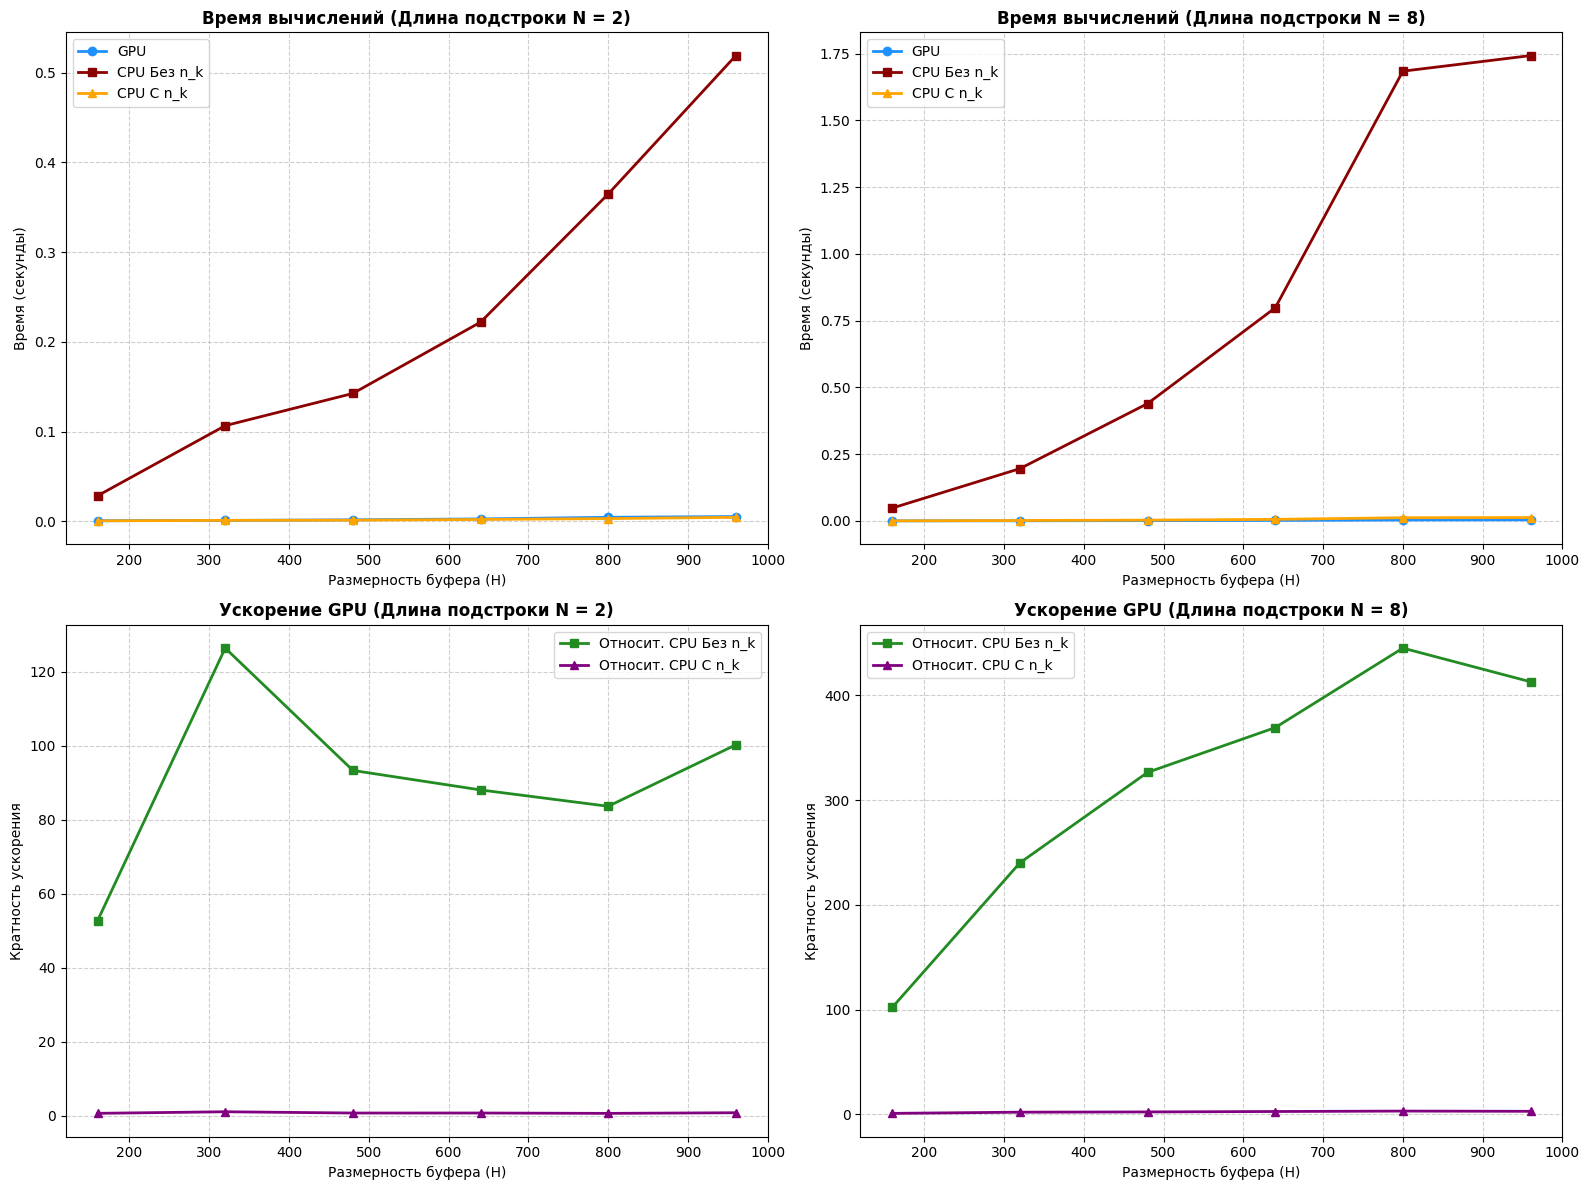

In [14]:
if __name__ == "__main__":

    target_sizes = [160, 320, 480, 640, 800, 960]

    # min и max длины подстрок
    substring_lengths = [2, 8]

    print(f"Начало вычислительных экспериментов")
    print(f"Размерности буфера (H): {target_sizes}")
    print(f"Длины подстрок (N): {substring_lengths}\n")

    results_df = orchestrate_benchmarks(target_sizes, substring_lengths, iterations=3)

    results_df.to_csv("Benchmark_Final_Results.csv", index=False)
    print("\nОбщие результаты сохранены в 'Benchmark_Final_Results.csv'")

    # Визуализация графиков времени и ускорения
    print("Визуализация графиков")
    visualize_performance(results_df)

In [15]:
import pandas as pd

df_res = pd.read_csv('Benchmark_Final_Results.csv')

In [16]:
df_res

,Substring_Length,Buffer_Size,GPU_Time,CPU_Naive_Time,CPU_Indexed_Time,Correctness,Accel_Naive,Accel_Indexed
0,2,160,0.000538,0.028349,0.000362,PASS,52.722140,0.673515
1,2,320,0.000843,0.106538,0.000924,PASS,126.384180,1.096163
2,2,480,0.001527,0.142472,0.001152,PASS,93.326878,0.754646
3,2,640,0.002520,0.221935,0.001912,PASS,88.058336,0.758742
4,2,800,0.004362,0.364838,0.002897,PASS,83.642653,0.664243
5,2,960,0.005179,0.519214,0.004310,PASS,100.248872,0.832254
6,8,160,0.000474,0.048399,0.000507,PASS,102.163899,1.069955
7,8,320,0.000816,0.196012,0.001798,PASS,240.132801,2.202804
8,8,480,0.001346,0.439445,0.003281,PASS,326.435799,2.436980
9,8,640,0.002162,0.798022,0.006146,PASS,369.143592,2.842769
